Importing plotly failed. Interactive plots will not work.


Orders shape: (100000, 8)

Order status distribution:
order_status
Completed    90002
Cancelled     6862
Failed        3136
Name: count, dtype: int64

Completed orders: 90002

Hourly demand shape: (13081, 2)

Hourly demand sample:


,hour_timestamp,order_count
0,2025-01-01 00:00:00,5
1,2025-01-01 01:00:00,2
2,2025-01-01 02:00:00,1
3,2025-01-01 03:00:00,0
4,2025-01-01 04:00:00,4



Missing values:
hour_timestamp    0
order_count       0
dtype: int64


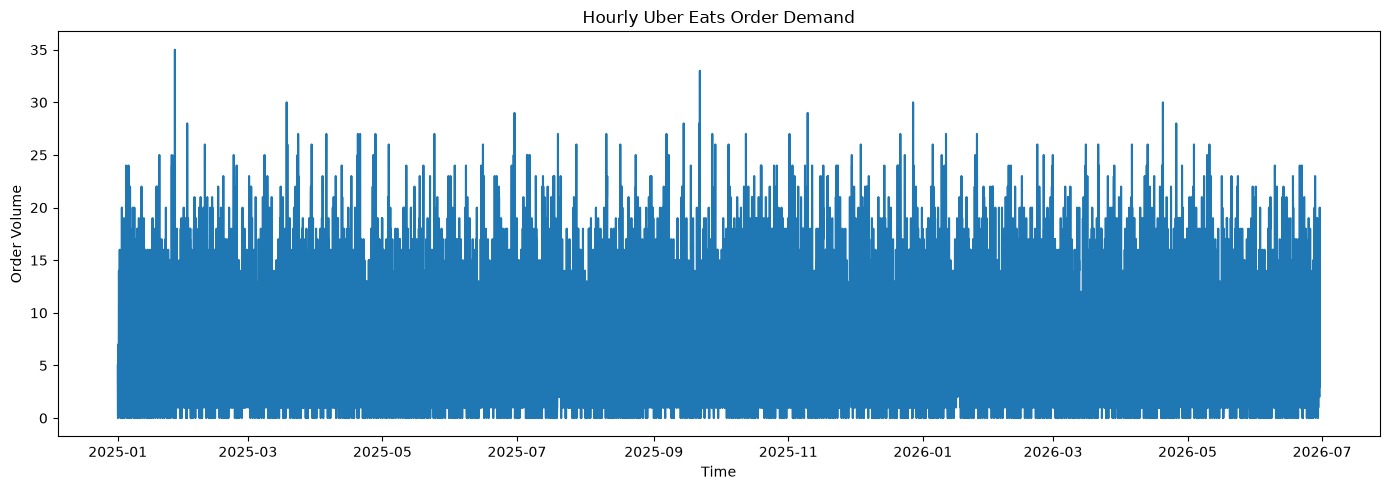

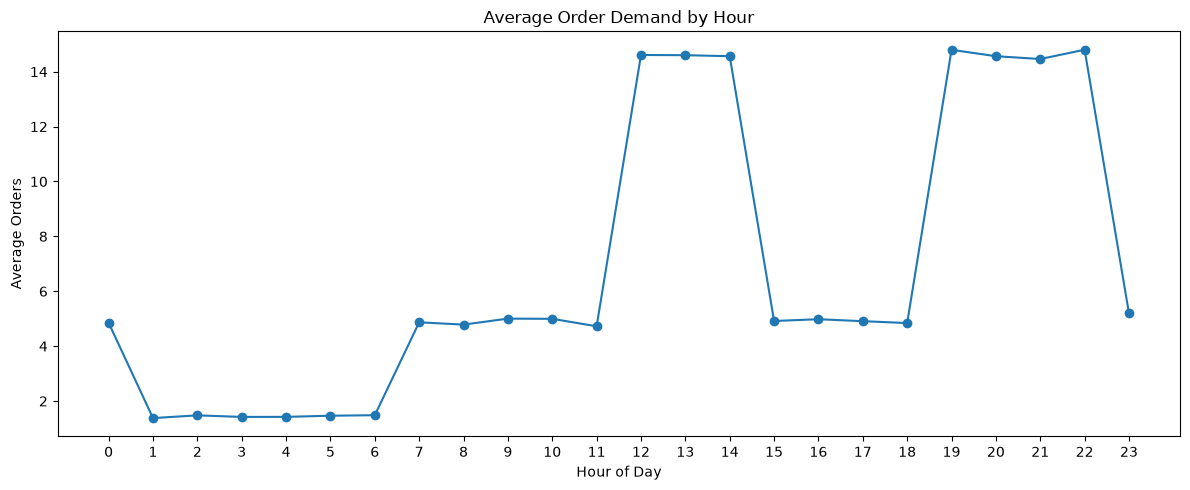


Peak ordering hours:
hour
22    14.800000
19    14.798165
12    14.609174
13    14.601835
20    14.565138
Name: order_count, dtype: float64


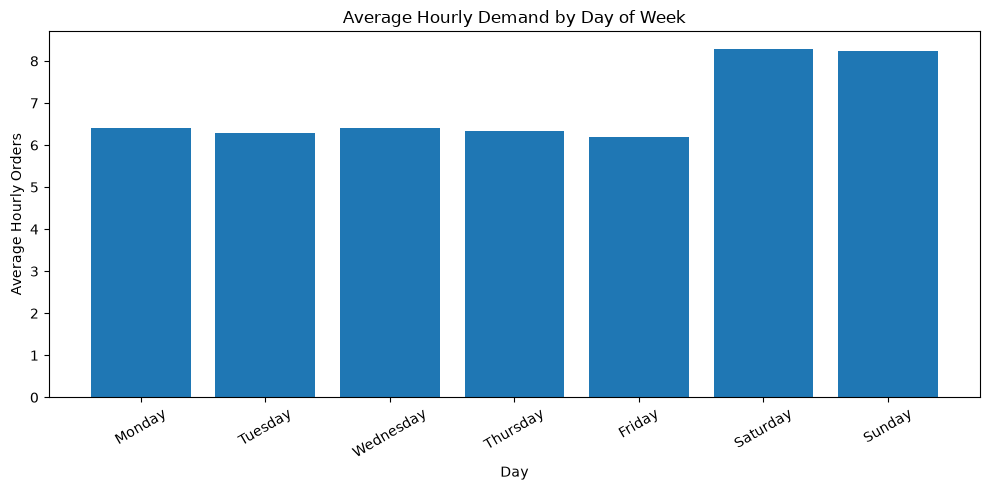


Average hourly demand by day:
day_name
Monday       6.413996
Tuesday      6.282315
Wednesday    6.401709
Thursday     6.337073
Friday       6.197115
Saturday     8.290598
Sunday       8.232372
Name: order_count, dtype: float64

Weekday vs Weekend:
is_weekend
False    6.326550
True     8.261485
Name: order_count, dtype: float64


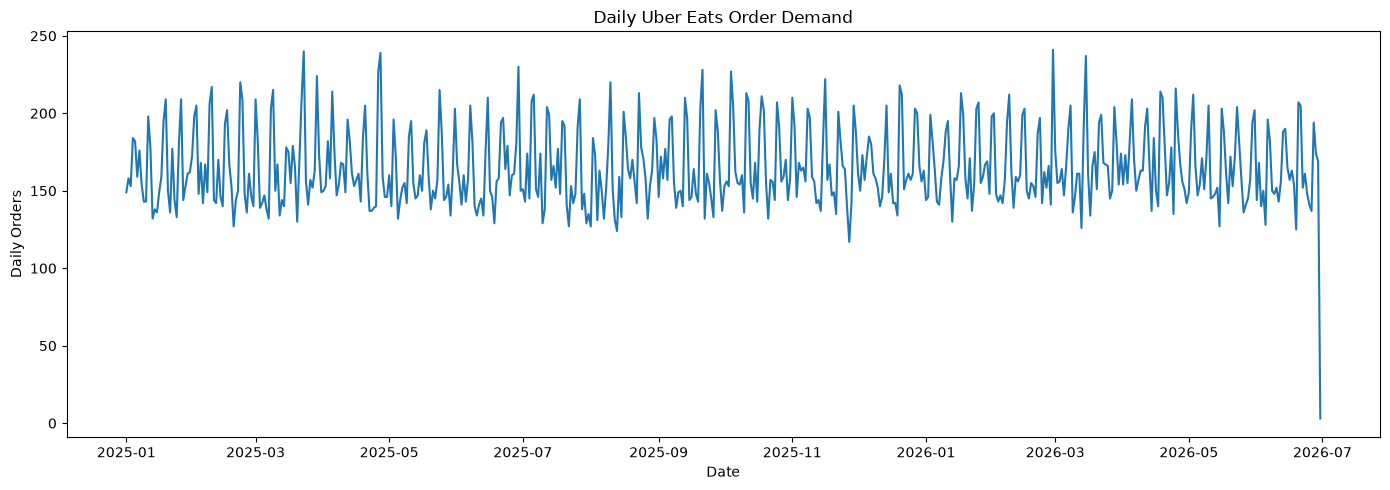

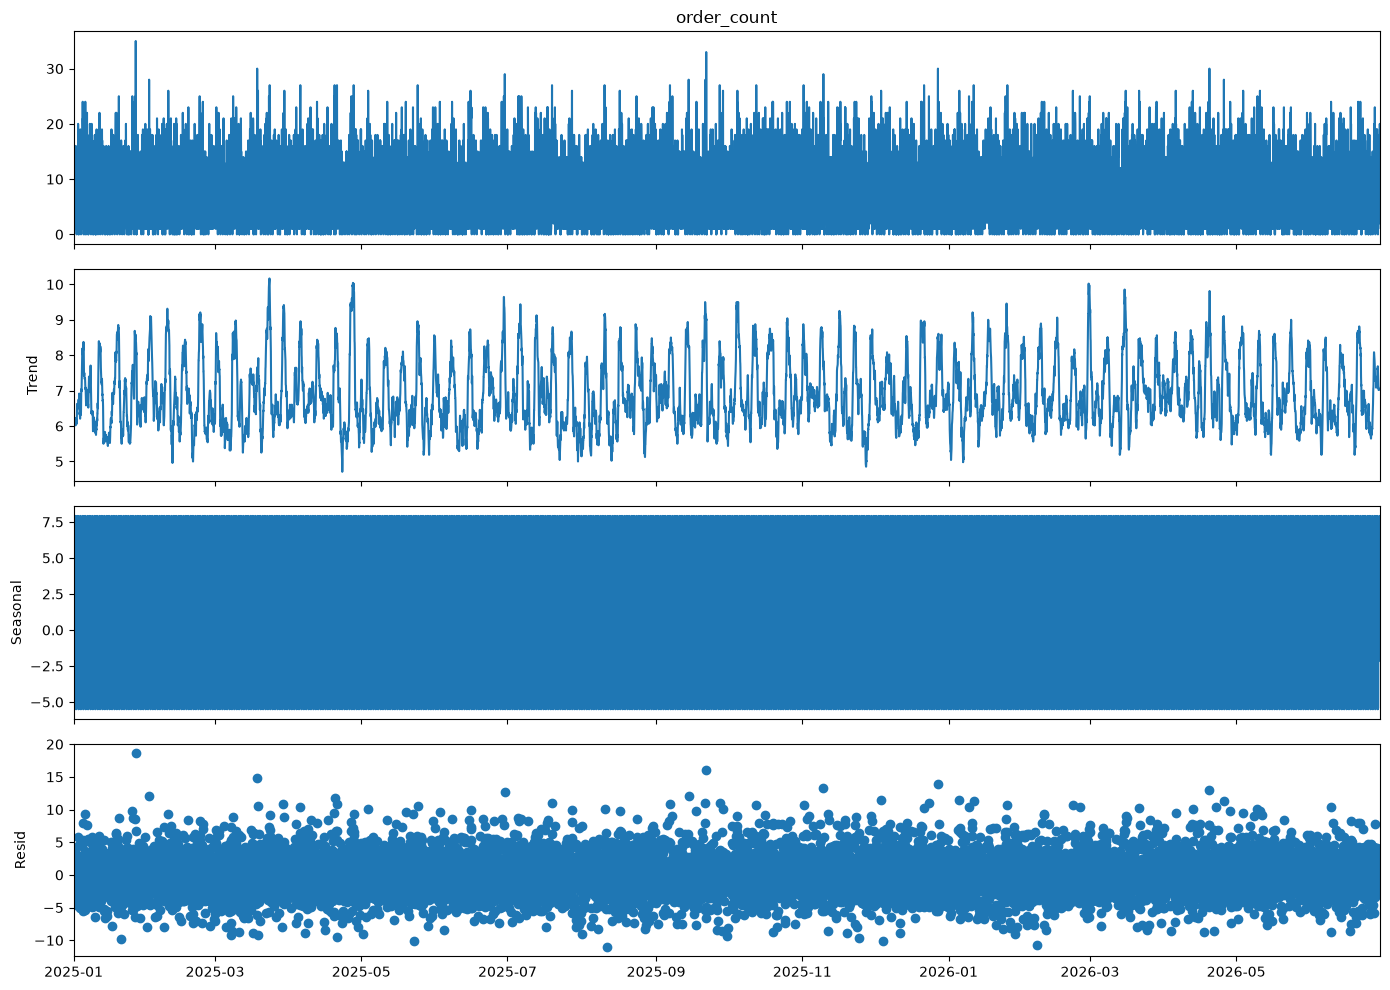


ADF Test - Original Hourly Demand
----------------------------------------
ADF Statistic : -19.0690
p-value       : 0.000000
Conclusion    : Stationary

ADF Test - First Differenced Hourly Demand
----------------------------------------
ADF Statistic : -23.3295
p-value       : 0.000000
Conclusion    : Stationary


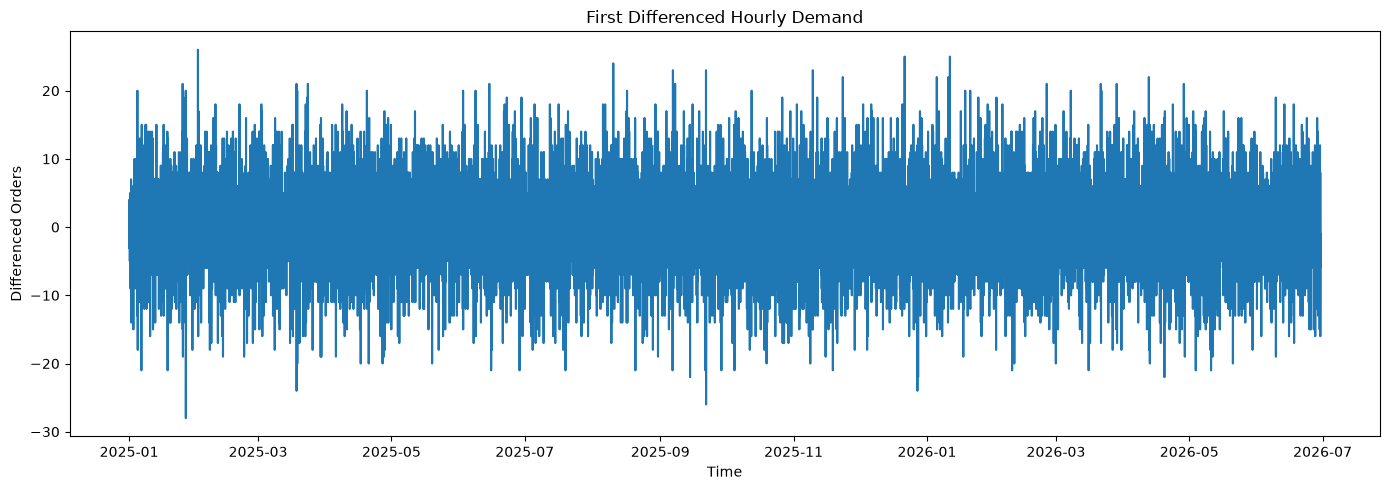


Chronological Split
----------------------------------------
Training samples: 10464
Testing samples : 2617

Training period:
2025-01-01 00:00:00 to 2026-03-12 23:00:00

Testing period:
2026-03-13 00:00:00 to 2026-06-30 00:00:00

Training ARIMA (3, 1, 3) ...

ARIMA Performance
----------------------------------------
MAE  : 4.8400
RMSE : 5.9308
MAPE : 132.21%


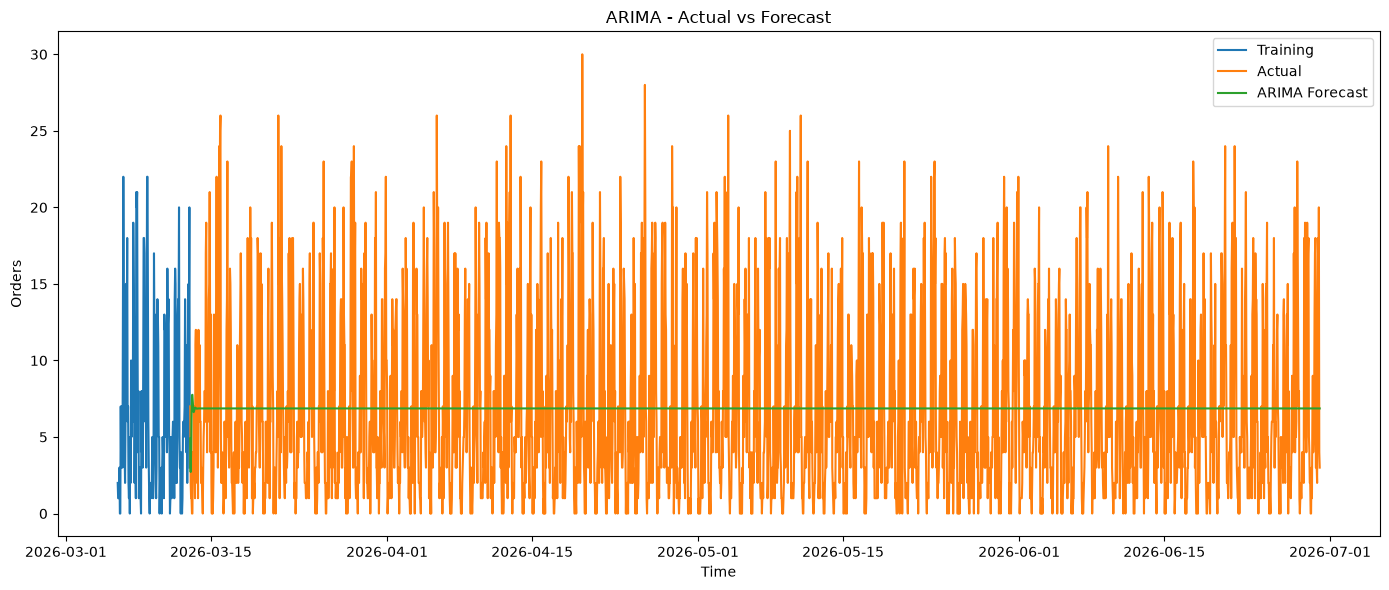

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.



Training Prophet...


10:20:20 - cmdstanpy - INFO - Chain [1] start processing
10:20:21 - cmdstanpy - INFO - Chain [1] done processing



Prophet Performance
----------------------------------------
MAE  : 2.3560
RMSE : 3.1486
MAPE : 55.96%


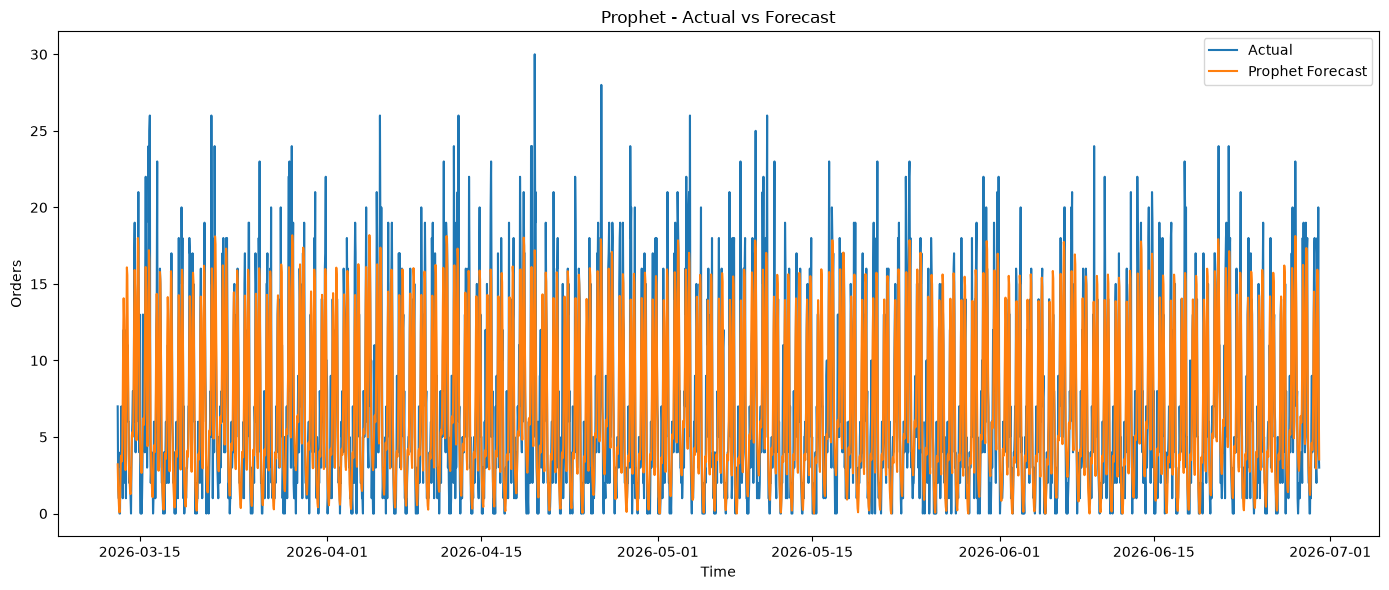


MODEL COMPARISON


,Model,MAE,RMSE,MAPE
1,Prophet,2.356047,3.148636,55.959325
0,ARIMA,4.840020,5.930817,132.212195


Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.



Best Model: Prophet


10:20:22 - cmdstanpy - INFO - Chain [1] start processing
10:20:23 - cmdstanpy - INFO - Chain [1] done processing


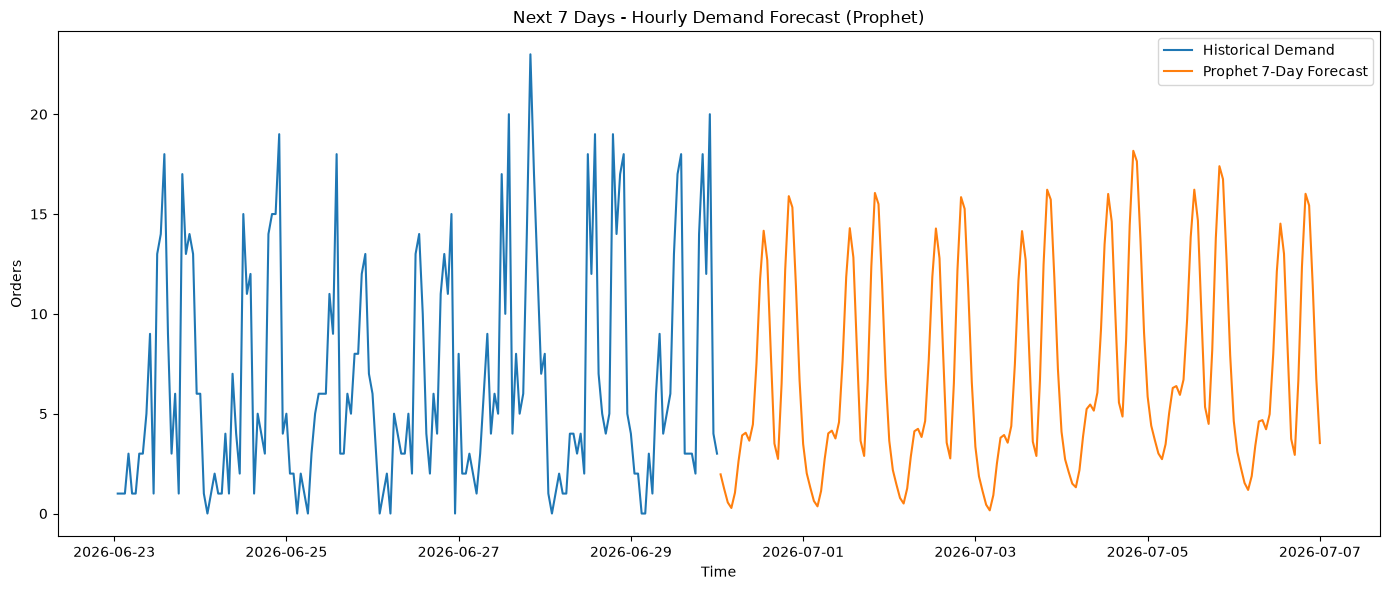


NEXT 7 DAYS DEMAND FORECAST


,timestamp,forecast_orders
0,2026-06-30 01:00:00,1.961836
1,2026-06-30 02:00:00,1.231329
2,2026-06-30 03:00:00,0.555563
3,2026-06-30 04:00:00,0.278537
4,2026-06-30 05:00:00,1.041192
5,2026-06-30 06:00:00,2.632186
6,2026-06-30 07:00:00,3.914292
7,2026-06-30 08:00:00,4.045543
8,2026-06-30 09:00:00,3.649816
9,2026-06-30 10:00:00,4.463931



Total forecasted orders for next 7 days: 1196
Average forecasted hourly demand: 7.12
Peak forecasted hourly demand: 18.17

Files saved:
../data/processed/hourly_demand.csv
../data/processed/demand_forecast_model_comparison.csv
../data/processed/final_demand_forecast.csv

DAY 5 SUMMARY
Hourly demand observations: 13081
Training observations: 10464
Testing observations: 2617

ARIMA:
MAE  : 4.8400
RMSE : 5.9308
MAPE : 132.21%

Prophet:
MAE  : 2.3560
RMSE : 3.1486
MAPE : 55.96%

Best Model: Prophet

Day 5 forecasting pipeline completed.


In [3]:
# ============================================================
# DAY 5 - HOURLY DEMAND FORECASTING
# Uber Eats ML Capstone
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet
try:
    from prophet import Prophet
    prophet_available = True
except ImportError:
    prophet_available = False
    print("WARNING: Prophet is not installed.")
    print("Run this once in a notebook cell if required:")
    print("!pip install prophet")


# ============================================================
# 2. LOAD ORDERS DATA
# ============================================================

orders_path = "../data/raw/orders.csv"

orders = pd.read_csv(orders_path)

orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

print("Orders shape:", orders.shape)
print("\nOrder status distribution:")
print(orders["order_status"].value_counts())


# ============================================================
# 3. FILTER COMPLETED ORDERS
# ============================================================

completed_orders = orders[
    orders["order_status"].str.lower() == "completed"
].copy()

print("\nCompleted orders:", len(completed_orders))


# ============================================================
# 4. CREATE HOURLY DEMAND DATASET
# ============================================================

completed_orders["hour_timestamp"] = (
    completed_orders["order_timestamp"]
    .dt.floor("h")
)

hourly_demand = (
    completed_orders
    .groupby("hour_timestamp")
    .size()
    .reset_index(name="order_count")
    .sort_values("hour_timestamp")
)

# Create a complete hourly time index
full_hours = pd.date_range(
    start=hourly_demand["hour_timestamp"].min(),
    end=hourly_demand["hour_timestamp"].max(),
    freq="h"
)

hourly_demand = (
    hourly_demand
    .set_index("hour_timestamp")
    .reindex(full_hours, fill_value=0)
    .rename_axis("hour_timestamp")
    .reset_index()
)

print("\nHourly demand shape:", hourly_demand.shape)
print("\nHourly demand sample:")
display(hourly_demand.head())

print("\nMissing values:")
print(hourly_demand.isna().sum())


# ============================================================
# 5. ADD TIME FEATURES FOR EDA
# ============================================================

hourly_demand["hour"] = hourly_demand["hour_timestamp"].dt.hour
hourly_demand["day_of_week"] = hourly_demand["hour_timestamp"].dt.dayofweek
hourly_demand["day_name"] = hourly_demand["hour_timestamp"].dt.day_name()
hourly_demand["is_weekend"] = (
    hourly_demand["day_of_week"] >= 5
)


# ============================================================
# 6. BASIC TIME-SERIES EDA
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    hourly_demand["hour_timestamp"],
    hourly_demand["order_count"]
)

plt.xlabel("Time")
plt.ylabel("Order Volume")
plt.title("Hourly Uber Eats Order Demand")

plt.tight_layout()
plt.show()


# ============================================================
# 7. HOURLY ORDERING PATTERN
# ============================================================

hourly_pattern = (
    hourly_demand
    .groupby("hour")["order_count"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Orders")
plt.title("Average Order Demand by Hour")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

print("\nPeak ordering hours:")
print(
    hourly_pattern
    .sort_values(ascending=False)
    .head(5)
)


# ============================================================
# 8. DAY-OF-WEEK PATTERN
# ============================================================

weekday_pattern = (
    hourly_demand
    .groupby("day_name")["order_count"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_pattern = weekday_pattern.reindex(day_order)

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_pattern.index,
    weekday_pattern.values
)

plt.xlabel("Day")
plt.ylabel("Average Hourly Orders")
plt.title("Average Hourly Demand by Day of Week")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print("\nAverage hourly demand by day:")
print(weekday_pattern)


# ============================================================
# 9. WEEKDAY VS WEEKEND
# ============================================================

weekend_pattern = (
    hourly_demand
    .groupby("is_weekend")["order_count"]
    .mean()
)

print("\nWeekday vs Weekend:")
print(weekend_pattern)


# ============================================================
# 10. DAILY DEMAND FOR TREND VISUALIZATION
# ============================================================

daily_demand = (
    completed_orders
    .assign(
        order_date=completed_orders["order_timestamp"].dt.date
    )
    .groupby("order_date")
    .size()
    .reset_index(name="order_count")
)

daily_demand["order_date"] = pd.to_datetime(
    daily_demand["order_date"]
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["order_date"],
    daily_demand["order_count"]
)

plt.xlabel("Date")
plt.ylabel("Daily Orders")
plt.title("Daily Uber Eats Order Demand")

plt.tight_layout()
plt.show()


# ============================================================
# 11. TIME-SERIES DECOMPOSITION
# ============================================================
# Hourly data has strong daily seasonality.
# Period = 24 means one complete day.

ts = (
    hourly_demand
    .set_index("hour_timestamp")["order_count"]
)

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()


# ============================================================
# 12. ADF STATIONARITY TEST
# ============================================================

def adf_test(series, name):
    result = adfuller(series.dropna())

    print(f"\nADF Test - {name}")
    print("-" * 40)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")

    if result[1] < 0.05:
        print("Conclusion    : Stationary")
    else:
        print("Conclusion    : Non-stationary")

    return result


adf_original = adf_test(
    ts,
    "Original Hourly Demand"
)


# ============================================================
# 13. DIFFERENCING
# ============================================================

ts_diff = ts.diff().dropna()

adf_diff = adf_test(
    ts_diff,
    "First Differenced Hourly Demand"
)

plt.figure(figsize=(14, 5))

plt.plot(ts_diff)

plt.xlabel("Time")
plt.ylabel("Differenced Orders")
plt.title("First Differenced Hourly Demand")

plt.tight_layout()
plt.show()


# ============================================================
# 14. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================
# IMPORTANT:
# No random shuffle for time-series forecasting.

split_index = int(len(ts) * 0.80)

train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

print("\nChronological Split")
print("-" * 40)
print("Training samples:", len(train))
print("Testing samples :", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())


# ============================================================
# 15. ARIMA MODEL
# ============================================================
# Simple ARIMA model.
# d=1 because differencing was required.
#
# We keep the model simple for the capstone instead
# of performing a large parameter grid search.

arima_order = (3, 1, 3)

print("\nTraining ARIMA", arima_order, "...")

arima_model = ARIMA(
    train,
    order=arima_order
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)


# ============================================================
# 16. FORECAST METRICS FUNCTION
# ============================================================

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # Avoid division by zero
    actual_array = np.array(actual)
    predicted_array = np.array(predicted)

    non_zero = actual_array != 0

    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual_array[non_zero] -
                 predicted_array[non_zero])
                / actual_array[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    return mae, rmse, mape


arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

print("\nARIMA Performance")
print("-" * 40)
print(f"MAE  : {arima_mae:.4f}")
print(f"RMSE : {arima_rmse:.4f}")
print(f"MAPE : {arima_mape:.2f}%")


# ============================================================
# 17. ARIMA FORECAST PLOT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index[-24 * 7:],
    train.iloc[-24 * 7:],
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    arima_forecast.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.xlabel("Time")
plt.ylabel("Orders")
plt.title("ARIMA - Actual vs Forecast")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 18. PROPHET MODEL
# ============================================================

prophet_mae = np.nan
prophet_rmse = np.nan
prophet_mape = np.nan

if prophet_available:

    # Prophet requires columns:
    # ds = timestamp
    # y  = target

    prophet_train = (
        train
        .reset_index()
        .rename(
            columns={
                "hour_timestamp": "ds",
                "order_count": "y"
            }
        )
    )

    prophet_test = (
        test
        .reset_index()
        .rename(
            columns={
                "hour_timestamp": "ds",
                "order_count": "y"
            }
        )
    )

    print("\nTraining Prophet...")

    prophet_model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True
    )

    prophet_model.fit(
        prophet_train
    )

    # Forecast exactly the test period
    future_test = prophet_test[["ds"]].copy()

    prophet_prediction = prophet_model.predict(
        future_test
    )

    prophet_forecast = pd.Series(
        prophet_prediction["yhat"].values,
        index=test.index
    )

    # Demand cannot be negative
    prophet_forecast = prophet_forecast.clip(
        lower=0
    )

    prophet_mae, prophet_rmse, prophet_mape = calculate_metrics(
        test,
        prophet_forecast
    )

    print("\nProphet Performance")
    print("-" * 40)
    print(f"MAE  : {prophet_mae:.4f}")
    print(f"RMSE : {prophet_rmse:.4f}")
    print(f"MAPE : {prophet_mape:.2f}%")

    # Prophet forecast plot
    plt.figure(figsize=(14, 6))

    plt.plot(
        test.index,
        test,
        label="Actual"
    )

    plt.plot(
        prophet_forecast.index,
        prophet_forecast,
        label="Prophet Forecast"
    )

    plt.xlabel("Time")
    plt.ylabel("Orders")
    plt.title("Prophet - Actual vs Forecast")
    plt.legend()

    plt.tight_layout()
    plt.show()

else:

    print("\nProphet skipped because it is not installed.")
    print("Install it using:")
    print("!pip install prophet")


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "ARIMA",
        "Prophet"
    ],
    "MAE": [
        arima_mae,
        prophet_mae
    ],
    "RMSE": [
        arima_rmse,
        prophet_rmse
    ],
    "MAPE": [
        arima_mape,
        prophet_mape
    ]
})

print("\nMODEL COMPARISON")
print("=" * 60)

display(
    comparison.sort_values(
        "MAE"
    )
)


# ============================================================
# 20. SELECT BEST MODEL
# ============================================================

valid_comparison = comparison.dropna(
    subset=["MAE"]
)

best_model_name = (
    valid_comparison
    .sort_values("MAE")
    .iloc[0]["Model"]
)

print("\nBest Model:", best_model_name)


# ============================================================
# 21. FINAL 7-DAY DEMAND FORECAST
# ============================================================
# Forecast the next 168 hours = 7 days.

future_hours = 24 * 7

if best_model_name == "ARIMA":

    # Refit ARIMA on the complete time series
    final_arima = ARIMA(
        ts,
        order=arima_order
    ).fit()

    future_forecast = final_arima.forecast(
        steps=future_hours
    )

    future_index = pd.date_range(
        start=ts.index.max() + pd.Timedelta(hours=1),
        periods=future_hours,
        freq="h"
    )

    final_forecast = pd.DataFrame({
        "timestamp": future_index,
        "forecast_orders": np.maximum(
            future_forecast.values,
            0
        )
    })

else:

    # Refit Prophet on the complete dataset
    prophet_full = (
        ts
        .reset_index()
        .rename(
            columns={
                "hour_timestamp": "ds",
                "order_count": "y"
            }
        )
    )

    final_prophet = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True
    )

    final_prophet.fit(
        prophet_full
    )

    future = final_prophet.make_future_dataframe(
        periods=future_hours,
        freq="h",
        include_history=False
    )

    future_prediction = final_prophet.predict(
        future
    )

    final_forecast = pd.DataFrame({
        "timestamp": future["ds"],
        "forecast_orders": np.maximum(
            future_prediction["yhat"].values,
            0
        )
    })


# ============================================================
# 22. FINAL FORECAST PLOT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    ts.index[-24 * 7:],
    ts.iloc[-24 * 7:],
    label="Historical Demand"
)

plt.plot(
    final_forecast["timestamp"],
    final_forecast["forecast_orders"],
    label=f"{best_model_name} 7-Day Forecast"
)

plt.xlabel("Time")
plt.ylabel("Orders")
plt.title(
    f"Next 7 Days - Hourly Demand Forecast ({best_model_name})"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 23. PRINT FORECAST
# ============================================================

print("\nNEXT 7 DAYS DEMAND FORECAST")
print("=" * 60)

display(
    final_forecast.head(20)
)

print(
    "\nTotal forecasted orders for next 7 days:",
    round(final_forecast["forecast_orders"].sum())
)

print(
    "Average forecasted hourly demand:",
    round(final_forecast["forecast_orders"].mean(), 2)
)

print(
    "Peak forecasted hourly demand:",
    round(final_forecast["forecast_orders"].max(), 2)
)


# ============================================================
# 24. SAVE DELIVERABLES
# ============================================================

# Hourly demand dataset
hourly_path = "../data/processed/hourly_demand.csv"

hourly_demand.to_csv(
    hourly_path,
    index=False
)


# Model comparison
comparison_path = (
    "../data/processed/demand_forecast_model_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)


# Final forecast
forecast_path = (
    "../data/processed/final_demand_forecast.csv"
)

final_forecast.to_csv(
    forecast_path,
    index=False
)


print("\nFiles saved:")
print(hourly_path)
print(comparison_path)
print(forecast_path)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("DAY 5 SUMMARY")
print("=" * 60)

print("Hourly demand observations:", len(hourly_demand))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nARIMA:")
print(f"MAE  : {arima_mae:.4f}")
print(f"RMSE : {arima_rmse:.4f}")
print(f"MAPE : {arima_mape:.2f}%")

if prophet_available:
    print("\nProphet:")
    print(f"MAE  : {prophet_mae:.4f}")
    print(f"RMSE : {prophet_rmse:.4f}")
    print(f"MAPE : {prophet_mape:.2f}%")

print("\nBest Model:", best_model_name)

print("\nDay 5 forecasting pipeline completed.")

In [2]:
 %pip install prophet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 3.9 MB/s  0:00:03 eta 0:00:010:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.9 MB/s  0:00:009.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [prophet]━━━ 3/4 [prophet]]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/nineleaps/Automation/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
